# 01 - Preparación inicial de los datos

En este notebook se realiza la preparación inicial del dataset original.

Este notebook no realiza ningún tipo de normalización estadística, escalado, imputación ni codificación de variables.


Se limita el número de hilos utilizados por algunas librerías numéricas para evitar sobrecarga computacional en ciertos entornos.

In [118]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [119]:

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
RUTA_DATOS_ORIGINALES = Path("Imputados Version 1.xlsx")
RUTA_DATOS_SALIDA = Path("datos_preparados_v1.pkl")


Se carga el archivo Excel original y se inspeccionan sus dimensiones, las primeras filas y un resumen estadístico básico.

In [121]:
df_original = pd.read_excel(RUTA_DATOS_ORIGINALES)

print("Dimensiones del dataset original:")
print(df_original.shape)

display(df_original.head())
display(df_original.describe())

Dimensiones del dataset original:
(300, 213)


c:\Users\vicen\anaconda3\envs\nlp3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


,N,Sexo,Edad,Onco_Hem,Dx_Onco,Dx_Hemato,OncoLinf,Fecha_Dx,Charlson,Estadio_Dx,...,Inflamacion,sarcopenia,mioesteatosis,Crit_FenSMI,DESGLIMSMI,Crit_FenSARC,DESGLIMSARC,ObSarc,ObSarc2,gradoIMC
0,1,0,67,0,1.0,NaN,0,42217.0,6,4.0,...,NaN,0.0,1.0,2.0,1.0,1.0,1.0,0.0,0.0,1.0
1,2,0,68,0,0.0,NaN,0,42278.0,6,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0
2,3,0,77,0,2.0,NaN,0,42583.0,6,4.0,...,NaN,0.0,1.0,2.0,1.0,1.0,1.0,0.0,0.0,1.0
3,4,0,67,1,NaN,3.0,0,42248.0,2,4.0,...,NaN,1.0,1.0,2.0,1.0,2.0,1.0,0.0,0.0,1.0
4,5,0,57,1,NaN,3.0,0,37834.0,2,4.0,...,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0


,N,Sexo,Edad,Onco_Hem,Dx_Onco,Dx_Hemato,OncoLinf,Fecha_Dx,Charlson,Estadio_Dx,...,Inflamacion,sarcopenia,mioesteatosis,Crit_FenSMI,DESGLIMSMI,Crit_FenSARC,DESGLIMSARC,ObSarc,ObSarc2,gradoIMC
count,300.000000,300.000000,300.000000,300.000000,248.000000,52.000000,300.000000,295.000000,300.000000,287.000000,...,0.0,267.000000,266.000000,262.000000,262.000000,262.000000,262.000000,291.000000,290.000000,299.000000
mean,150.430000,0.450000,60.323333,0.166667,4.084677,2.269231,0.060000,42023.288136,5.326667,2.749129,...,NaN,0.561798,0.642857,1.549618,0.885496,1.488550,0.881679,0.147766,0.120690,1.481605
min,1.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,33970.000000,2.000000,0.000000,...,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,75.750000,0.000000,54.000000,0.000000,1.000000,1.000000,0.000000,41959.000000,3.000000,2.000000,...,NaN,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
50%,150.000000,0.000000,62.000000,0.000000,3.000000,3.000000,0.000000,42461.000000,6.000000,3.000000,...,NaN,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,225.250000,1.000000,70.000000,0.000000,7.000000,3.000000,0.000000,42843.500000,7.000000,4.000000,...,NaN,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,0.000000,0.000000,2.000000
max,300.000000,1.000000,82.000000,1.000000,11.000000,6.000000,1.000000,43140.000000,11.000000,4.000000,...,NaN,1.000000,1.000000,3.000000,1.000000,3.000000,1.000000,1.000000,1.000000,3.000000
std,86.755635,0.498325,12.578268,0.373301,3.335020,1.401895,0.237884,1379.682366,2.096331,1.394215,...,NaN,0.497098,0.480061,0.868466,0.319032,0.860957,0.323606,0.355480,0.326329,0.791415


In [122]:
print("Columnas finales del dataset original:")
print(df_original.columns[202:214])

Columnas finales del dataset original:
Index(['IMC_bajo', 'Inflamacion', 'sarcopenia', 'mioesteatosis', 'Crit_FenSMI',
       'DESGLIMSMI', 'Crit_FenSARC', 'DESGLIMSARC', 'ObSarc', 'ObSarc2',
       'gradoIMC'],
      dtype='object')



Se eliminan todas las columnas cuyo nombre contiene la cadena `"fec"`, independientemente de si aparece en mayúsculas o minúsculas.

Estas variables se eliminan porque, en esta fase inicial, no se van a utilizar como variables predictoras ni descriptivas.

In [123]:
columnas_fecha = [
    col for col in df_original.columns
    if "fec" in col.lower()
]

df_limpio = df_original.drop(columns=columnas_fecha)

print("Columnas de fecha eliminadas:")
print(columnas_fecha)

print("Dimensiones después de eliminar columnas de fecha:")
print(df_limpio.shape)

Columnas de fecha eliminadas:
['Fecha_Dx', 'FechaIng', 'FecAlta', 'Reing_Fecha', 'Fecha_Exitus', 'Fecha_TC']
Dimensiones después de eliminar columnas de fecha:
(300, 207)


Se eliminan las variables `Observ` y `MotivIng`, ya que contienen texto libre y no pueden utilizar en el analisis.

La variable `N`, que identifica al paciente, se conserva por ahora. Más adelante se decidirá si debe eliminarse antes de realizar análisis estadísticos o modelos predictivos.

In [124]:
columnas_texto = ["Observ", "MotivIng"]

df_limpio = df_limpio.drop(columns=columnas_texto)

print("Columnas de texto eliminadas:")
print(columnas_texto)

print("Dimensiones después de eliminar columnas de texto:")
print(df_limpio.shape)

Columnas de texto eliminadas:
['Observ', 'MotivIng']
Dimensiones después de eliminar columnas de texto:
(300, 205)


Se va a corregir de forma automática los tipos de las variables del fichero.

La lógica para procesar las variables es:

- Si una variable numérica tiene 1 o 2 valores distintos, se convierte a tipo `boolean`.
- Si una variable numérica tiene entre 3 y 12 valores distintos, se convierte a tipo `category`.
- Las variables con 13 o más valores distintos se mantienen como numéricas.

Debe tenerse en cuenta que `nunique()` no cuenta los valores nulos por defecto.

Algunas variables se fuerzan manualmente a tipos concretos para seguir las instrucciones del diccionario de datos que vino con el fichero de datos de los pacientes.

In [125]:
for col in df_limpio.select_dtypes(include="number").columns:
    n_valores = df_limpio[col].nunique()

    if n_valores < 13:
        if n_valores <= 2:
            df_limpio[col] = df_limpio[col].astype("boolean")
        else:
            df_limpio[col] = df_limpio[col].astype("category")


df_limpio[["Charlson", "ECOGalta", "ECOGing"]] = (
    df_limpio[["Charlson", "ECOGalta", "ECOGing"]].astype("Int64")
)

df_limpio["FactEstr"] = df_limpio["FactEstr"].astype("float64")


df_limpio[["Crit_FenIMM", "Crit_FenPB", "Crit_FenPB10", "Crit_FenDin", 
      "Crit_FenDin10", "Crit_FenCMB", "Crit_FenCMB10", "Crit_FenSARC","Crit_FenSMI"]] = df_limpio[["Crit_FenIMM", "Crit_FenPB", "Crit_FenPB10", "Crit_FenDin", 
      "Crit_FenDin10", "Crit_FenCMB", "Crit_FenCMB10", "Crit_FenSARC","Crit_FenSMI"]].astype("Int64")


Se calcula el número y el porcentaje de valores perdidos por variable y se representa un mapa de valores perdidos para visualizar la distribución de los datos ausentes en el dataset.

Número de valores perdidos por variable:


N                0
Sexo             0
Edad             0
Onco_Hem         0
Dx_Onco         52
                ..
Crit_FenSARC    38
DESGLIMSARC     38
ObSarc           9
ObSarc2         10
gradoIMC         1
Length: 205, dtype: int64

Porcentaje de valores perdidos por variable:


Inflamacion              100.000000
Criterios_Etiologicos    100.000000
Atenuac                  100.000000
VitD_1                    98.666667
PesAltA                   96.333333
                            ...    
N                          0.000000
Charlson                   0.000000
OncoLinf                   0.000000
TC1anyo                    0.000000
Paliat                     0.000000
Length: 205, dtype: float64

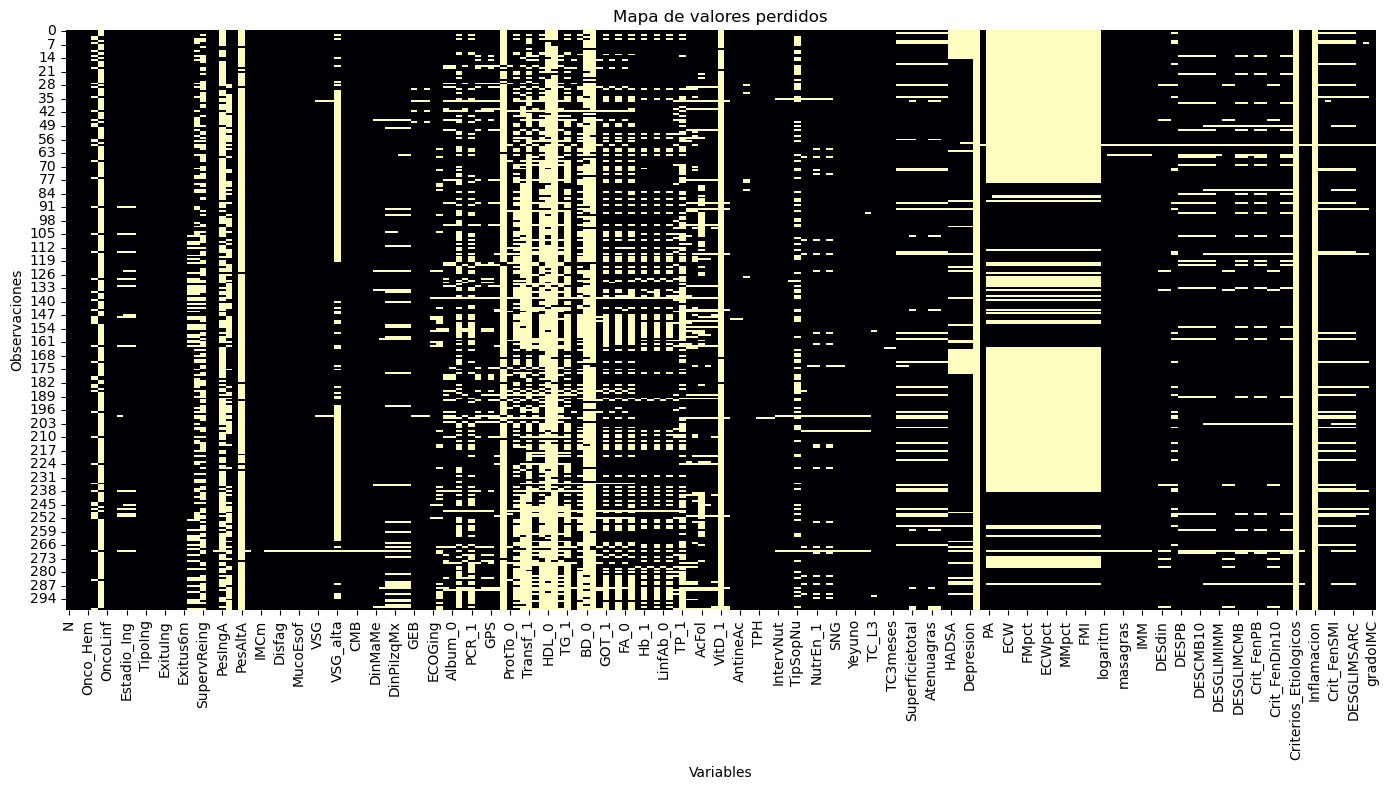

In [126]:
nulos_por_variable = df_limpio.isnull().sum()
porcentaje_nulos = df_limpio.isnull().mean().mul(100).sort_values(ascending=False)

print("Número de valores perdidos por variable:")
display(nulos_por_variable)

print("Porcentaje de valores perdidos por variable:")
display(porcentaje_nulos)

plt.figure(figsize=(14, 8))
sns.heatmap(df_limpio.isnull(), cmap="magma", cbar=False)

plt.title("Mapa de valores perdidos")
plt.xlabel("Variables")
plt.ylabel("Observaciones")
plt.tight_layout()
plt.show()

Visualizamos graficamente las 50 variables con mayor porcentaje de NAs

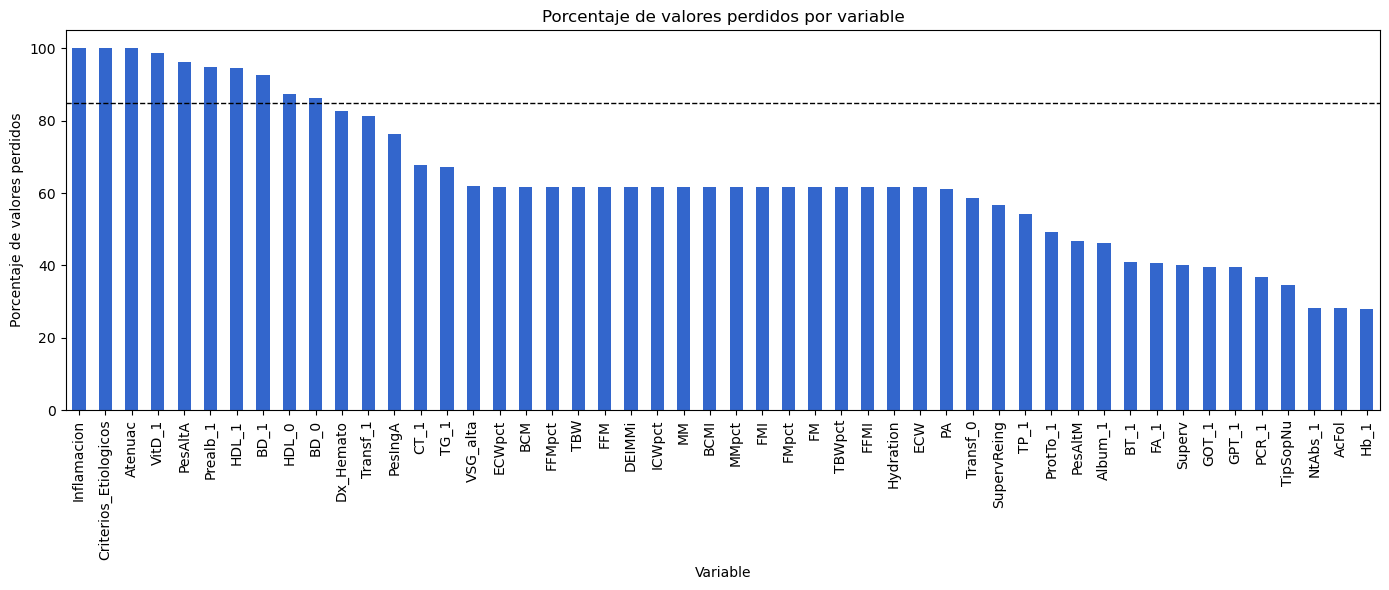

In [127]:
plt.figure(figsize=(14, 6))
porcentaje_nulos.head(50).plot(kind="bar", color=(0.2, 0.4, 0.8))

plt.axhline(85, linestyle="--", linewidth=1, color="black")
plt.title("Porcentaje de valores perdidos por variable")
plt.ylabel("Porcentaje de valores perdidos")
plt.xlabel("Variable")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Se eliminan las variables que tienen más del 85% de valores perdidos.

In [128]:
variables_NA85 = [
    col for col in df_limpio.columns
    if df_limpio[col].isnull().mean() > 0.85
]

df_limpio = df_limpio.drop(columns=variables_NA85)

print("Variables eliminadas por tener más del 85% de valores perdidos:")
print(variables_NA85)

print("Número de variables eliminadas:")
print(len(variables_NA85))

print("Dimensiones después de eliminar variables con >85% de valores perdidos:")
print(df_limpio.shape)

Variables eliminadas por tener más del 85% de valores perdidos:
['PesAltA', 'Prealb_1', 'HDL_0', 'HDL_1', 'BD_0', 'BD_1', 'VitD_1', 'Atenuac', 'Criterios_Etiologicos', 'Inflamacion']
Número de variables eliminadas:
10
Dimensiones después de eliminar variables con >85% de valores perdidos:
(300, 195)


Eliminamos las variables de criterio de desnutrición ya que como sirven la misma función, su función se hace redundante y nos quedamos solo con "DESGLIMSMI" como criterio principal de desnutrición.

In [129]:
variables_desnutricion_a_eliminar = [
    "DESIMM",
    "DESIMC",
    "DESdin",
    "DESdin10",
    "DESSMI",
    "DESPB",
    "DESPB10",
    "DESCMB",
    "DESCMB10",
    "DESGLIMPB",
    "DESGLIMPB10",
    "DESGLIMIMM",
    "DESGLIMDin",
    "DESGLIMDin10",
    "DESGLIMCMB",
    "DESGLIMCMB10",
    "DESGLIMCMB10",
    "DESGLIMSARC",
]

df_limpio = df_limpio.drop(columns=variables_desnutricion_a_eliminar)

print("Dimensiones después de eliminar criterios de desnutrición redundantes:")
print(df_limpio.shape)

Dimensiones después de eliminar criterios de desnutrición redundantes:
(300, 178)


Se hace lo mismo con las variables redundantes de criterios fenotípicos, en este punto se conserva `Crit_FenSARC` como criterio fenotípico principal.

In [130]:
variables_fenotipo_a_eliminar = [
    "Crit_FenIMM",
    "Crit_FenPB",
    "Crit_FenPB10",
    "Crit_FenDin",
    "Crit_FenDin10",
    "Crit_FenCMB",
    "Crit_FenCMB10",
]

df_limpio = df_limpio.drop(columns=variables_fenotipo_a_eliminar)

print("Dimensiones después de eliminar criterios fenotípicos redundantes:")
print(df_limpio.shape)

Dimensiones después de eliminar criterios fenotípicos redundantes:
(300, 171)


Se comprueban las dimensiones finales del dataset preparado.

In [131]:
print("Dimensiones finales del dataset preparado:")
print(df_limpio.shape)

print("\nVariables Crit_Fen restantes:")
print([col for col in df_limpio.columns if "Crit_Fen" in col])

print("\nVariables DESGLIM restantes:")
print([col for col in df_limpio.columns if "DESGLIM" in col])

print("\n¿La variable N sigue en el dataset?")
print("N" in df_limpio.columns)

Dimensiones finales del dataset preparado:
(300, 171)

Variables Crit_Fen restantes:
['Crit_FenSMI', 'Crit_FenSARC']

Variables DESGLIM restantes:
['DESGLIMSMI']

¿La variable N sigue en el dataset?
True


Se guarda el dataset preparado en formato `pickle` para conservar los tipos de datos de pandas y los otros canvios hechos.

Este archivo será utilizado como entrada en los siguientes notebooks de análisis.

In [132]:
df_limpio.to_pickle(RUTA_DATOS_SALIDA)

print(f"Dataset preparado guardado correctamente en: {RUTA_DATOS_SALIDA}")

Dataset preparado guardado correctamente en: datos_preparados_v1.pkl
